## Apple Import & Retail Price Analysis — Israel 2021–2025

Analysis of the impact of Israel's 2022–2023 agricultural tariff reform on apple import volumes and consumer prices.

**Data sources:**
- `Retail.csv` — monthly average consumer price (₪/kg)
- `IMPORT.csv` — monthly apple import volume (tons) and value (NIS) by country of origin

**Tariff history:**
- Until Feb-2022: 1.81 ₪/kg
- From Mar-2022: 1.53 ₪/kg (first reduction)
- From Jan-2023: 1.34 ₪/kg (second reduction)

In [7]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as mticker
import matplotlib.dates as mdates

conn = sqlite3.connect(":memory:")
retail = pd.read_csv("Retail.csv")
imp = pd.read_csv("IMPORT.csv", encoding="windows-1255")
imp.columns = imp.columns.str.strip()

# ← add these two lines
imp["Value_NIS"]    = imp["Value_NIS"].str.replace(",", "").astype(float)
imp["Quantity_TON"] = imp["Quantity_TON"].str.replace(",", "").astype(float)

retail.to_sql("Retail", conn, if_exists="replace", index=False)
imp.to_sql("Import", conn, if_exists="replace", index=False)

print("Tables loaded ✓")

Tables loaded ✓


## Query 1 & Query 2 — Monthly Aggregation

**Q1** aggregates import data by month across all countries of origin, joining with retail prices.  
**Q2** extends Q1 by adding `Import_Price_With_Tax` — the CIF import price plus the applicable tariff for each month.

`Import_Price` is calculated as: total NIS value / (total tons × 1000), giving ₪/kg.

In [8]:
q1 = """
SELECT
    i.Year,
    i.Month,
    SUM(i.Quantity_TON)                                                AS TON_Total,
    SUM(i.Value_NIS)                                                   AS NIS_Total,
    r.Price                                                            AS Price_Retail,
    CASE
        WHEN SUM(i.Quantity_TON) > 0
        THEN ROUND(SUM(i.Value_NIS) / (SUM(i.Quantity_TON) * 1000.0), 4)
        ELSE NULL
    END                                                                AS Import_Price
FROM Import i
LEFT JOIN Retail r
    ON i.Year = r.Year
    AND i.Month = r.Month
WHERE i.Year BETWEEN 2021 AND 2025
GROUP BY i.Year, i.Month, r.Price
ORDER BY i.Year, i.Month
"""

q2 = """
WITH q1 AS (
    SELECT
        i.Year,
        i.Month,
        SUM(i.Quantity_TON)                                             AS TON_Total,
        SUM(i.Value_NIS)                                                AS NIS_Total,
        r.Price                                                         AS Price_Retail,
        CASE
            WHEN SUM(i.Quantity_TON) > 0
            THEN ROUND(SUM(i.Value_NIS) / (SUM(i.Quantity_TON) * 1000.0), 4)
            ELSE NULL
        END                                                             AS Import_Price
    FROM Import i
    LEFT JOIN Retail r
        ON i.Year = r.Year
        AND i.Month = r.Month
    WHERE i.Year BETWEEN 2021 AND 2025
    GROUP BY i.Year, i.Month, r.Price
)
SELECT
    *,
    CASE
        WHEN Import_Price IS NOT NULL
        THEN ROUND(
            Import_Price
            + CASE
                WHEN Year < 2022                    THEN 1.81
                WHEN Year = 2022 AND Month <= 2     THEN 1.81
                WHEN Year = 2022 AND Month >= 3     THEN 1.53
                WHEN Year >= 2023                   THEN 1.34
              END
        , 4)
        ELSE NULL
    END                                                                 AS Import_Price_With_Tax
FROM q1
ORDER BY Year, Month
"""

df1 = pd.read_sql(q1, conn)
df2 = pd.read_sql(q2, conn)

print("Q1:", df1.shape)
display(df1)

print("Q2:", df2.shape)
display(df2)

Q1: (60, 6)


,Year,Month,TON_Total,NIS_Total,Price_Retail,Import_Price
0,2021,1,4176.0,22589266.0,10.143287,5.4093
1,2021,2,3138.0,16281327.0,10.371069,5.1884
2,2021,3,4659.0,25167591.0,10.443025,5.4019
3,2021,4,3790.0,20819423.0,10.860467,5.4933
4,2021,5,4345.0,22496592.0,11.098030,5.1776
5,2021,6,3444.0,18075866.0,11.252461,5.2485
6,2021,7,3366.0,16923791.0,11.280225,5.0279
7,2021,8,2428.0,14003360.0,11.212080,5.7674
8,2021,9,1743.0,8789425.0,10.928137,5.0427
9,2021,10,2323.0,13288224.0,10.698703,5.7203


Q2: (60, 7)


,Year,Month,TON_Total,NIS_Total,Price_Retail,Import_Price,Import_Price_With_Tax
0,2021,1,4176.0,22589266.0,10.143287,5.4093,7.2193
1,2021,2,3138.0,16281327.0,10.371069,5.1884,6.9984
2,2021,3,4659.0,25167591.0,10.443025,5.4019,7.2119
3,2021,4,3790.0,20819423.0,10.860467,5.4933,7.3033
4,2021,5,4345.0,22496592.0,11.098030,5.1776,6.9876
5,2021,6,3444.0,18075866.0,11.252461,5.2485,7.0585
6,2021,7,3366.0,16923791.0,11.280225,5.0279,6.8379
7,2021,8,2428.0,14003360.0,11.212080,5.7674,7.5774
8,2021,9,1743.0,8789425.0,10.928137,5.0427,6.8527
9,2021,10,2323.0,13288224.0,10.698703,5.7203,7.5303


## Annual Summary

Year-by-year totals for import volume, import value, and average retail price.

In [9]:
query = """
SELECT
    i.Year,
    ROUND(SUM(i.Quantity_TON))                                         AS TON_Total,
    ROUND(SUM(i.Value_NIS) / 1000000.0, 1)                            AS NIS_Million,
    ROUND(AVG(r.price), 2)                                             AS Avg_Retail_Price
FROM Import i
LEFT JOIN Retail r
    ON i.Year = r.Year
    AND i.Month = r.Month
GROUP BY i.Year
ORDER BY i.Year
"""

df_annual = pd.read_sql(query, conn)
df_annual

,Year,TON_Total,NIS_Million,Avg_Retail_Price
0,2021,41418.0,215.0,10.78
1,2022,44676.0,231.1,10.90
2,2023,39858.0,239.5,11.06
3,2024,60811.0,348.9,12.04
4,2025,66270.0,359.1,12.07


## Country Market Share

Italy has been the dominant supplier throughout the period.  
Left chart: yearly share breakdown. Right chart: overall 2021–2025 share.

In [10]:
query = """
SELECT
    Year,
    Country,
    ROUND(SUM(Quantity_TON)) AS TON_Total,
    ROUND(100.0 * SUM(Quantity_TON) / SUM(SUM(Quantity_TON)) OVER (PARTITION BY Year), 1) AS Share_Pct
FROM Import
GROUP BY Year, Country
ORDER BY Year, Share_Pct DESC
"""

df_share = pd.read_sql(query, conn)

# Top supplier per year
top = df_share.groupby('Year').first().reset_index()[['Year','Country','Share_Pct']]
top.columns = ['Year','Top Supplier','Share %']
print("=== Top Supplier by Year ===")
display(top)

# Overall across all years
query_overall = """
SELECT
    Country,
    ROUND(SUM(Quantity_TON)) AS TON_Total,
    ROUND(100.0 * SUM(Quantity_TON) / (SELECT SUM(Quantity_TON) FROM Import), 1) AS Share_Pct
FROM Import
GROUP BY Country
ORDER BY Share_Pct DESC
"""
df_overall = pd.read_sql(query_overall, conn)
print("\n=== Overall Market Share (2021–2025) ===")
display(df_overall)

=== Top Supplier by Year ===


,Year,Top Supplier,Share %
0,2021,איטליה,49.5
1,2022,איטליה,55.4
2,2023,איטליה,55.3
3,2024,איטליה,61.0
4,2025,איטליה,68.6



=== Overall Market Share (2021–2025) ===


,Country,TON_Total,Share_Pct
0,איטליה,149910.0,59.2
1,ארצות הברית,44031.0,17.4
2,אחר,29025.0,11.5
3,צרפת,17945.0,7.1
4,יוון,12122.0,4.8


## Visualization - Country Market Share

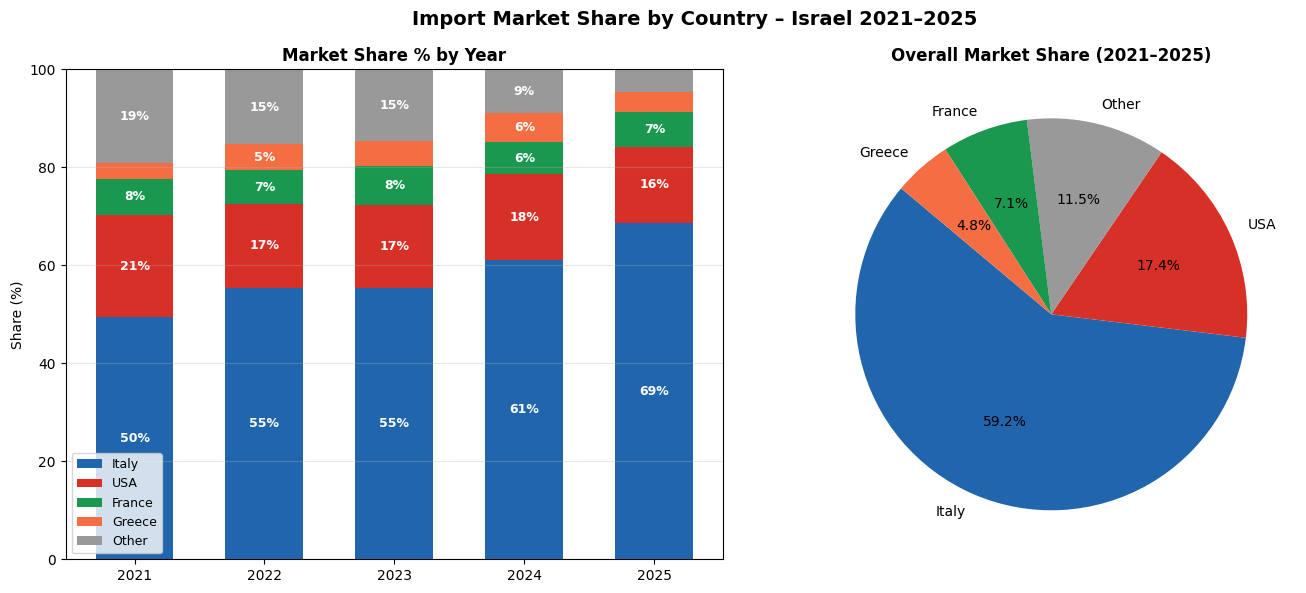

In [11]:
# Data prep
query = """
SELECT
    Year,
    Country,
    ROUND(SUM(Quantity_TON)) AS TON_Total,
    ROUND(100.0 * SUM(Quantity_TON) / SUM(SUM(Quantity_TON)) OVER (PARTITION BY Year), 1) AS Share_Pct
FROM Import
GROUP BY Year, Country
ORDER BY Year, Share_Pct DESC
"""
df_share = pd.read_sql(query, conn)

query_overall = """
SELECT Country,
    ROUND(SUM(Quantity_TON)) AS TON_Total,
    ROUND(100.0 * SUM(Quantity_TON) / (SELECT SUM(Quantity_TON) FROM Import), 1) AS Share_Pct
FROM Import
GROUP BY Country
ORDER BY Share_Pct DESC
"""
df_overall = pd.read_sql(query_overall, conn)

# Translate country names
country_map = {
    'איטליה':      'Italy',
    'ארצות הברית': 'USA',
    'צרפת':        'France',
    'יוון':        'Greece',
    'אחר':         'Other'
}
df_share['Country']   = df_share['Country'].map(country_map)
df_overall['Country'] = df_overall['Country'].map(country_map)

country_colors = {
    'Italy':  '#2166ac',
    'USA':    '#d73027',
    'France': '#1a9850',
    'Greece': '#f46d43',
    'Other':  '#999999'
}
countries = ['Italy', 'USA', 'France', 'Greece', 'Other']
years = sorted(df_share['Year'].unique())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Import Market Share by Country – Israel 2021–2025', fontsize=14, fontweight='bold')

# --- Chart 1: Stacked bar (% share) ---
ax1 = axes[0]
bottom = np.zeros(len(years))
for country in countries:
    vals = [
        df_share[(df_share['Year']==y) & (df_share['Country']==country)]['Share_Pct'].sum()
        for y in years
    ]
    ax1.bar(years, vals, bottom=bottom, label=country,
            color=country_colors[country], width=0.6)
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 5:
            ax1.text(years[i], b + v/2, f'{v:.0f}%',
                    ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    bottom += np.array(vals)

ax1.set_title('Market Share % by Year', fontweight='bold')
ax1.set_ylabel('Share (%)')
ax1.set_xticks(years)
ax1.set_ylim(0, 100)
ax1.legend(loc='lower left', fontsize=9)
ax1.grid(axis='y', alpha=0.3)

# --- Chart 2: Overall pie chart ---
ax2 = axes[1]
ax2.pie(
    df_overall['Share_Pct'],
    labels=df_overall['Country'],
    colors=[country_colors[c] for c in df_overall['Country']],
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 10}
)
ax2.set_title('Overall Market Share (2021–2025)', fontweight='bold')

plt.tight_layout()
plt.show()

## Monthly Import Volume

Shaded regions indicate the three tariff periods. Dashed vertical lines mark the two tariff reductions.  
A clear upward trend is visible, with volume increasing significantly after the January 2023 tariff cut.

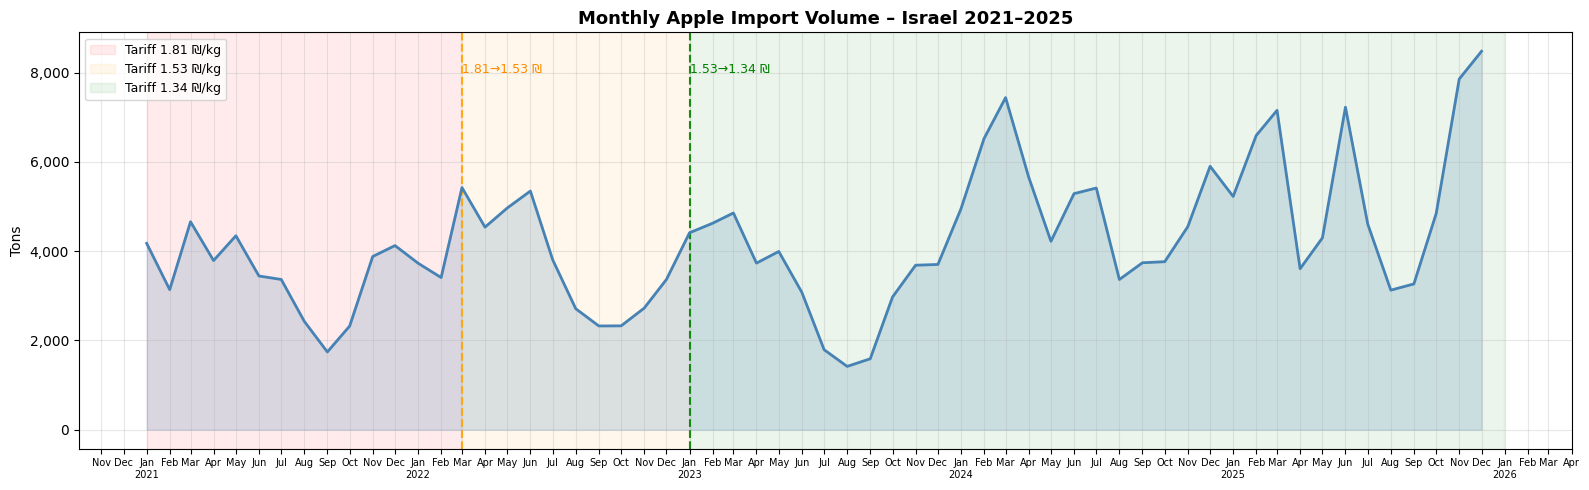

In [12]:
query = """
SELECT
    i.Year,
    i.Month,
    ROUND(SUM(i.Quantity_TON)) AS TON_Total
FROM Import i
GROUP BY i.Year, i.Month
ORDER BY i.Year, i.Month
"""
df_monthly = pd.read_sql(query, conn)
df_monthly['Date'] = pd.to_datetime(df_monthly[['Year','Month']].assign(Day=1))

fig, ax = plt.subplots(figsize=(16, 5))

# Shade tariff periods
ax.axvspan(pd.Timestamp('2021-01-01'), pd.Timestamp('2022-02-28'),
           alpha=0.08, color='red',    label='Tariff 1.81 ₪/kg')
ax.axvspan(pd.Timestamp('2022-03-01'), pd.Timestamp('2022-12-31'),
           alpha=0.08, color='orange', label='Tariff 1.53 ₪/kg')
ax.axvspan(pd.Timestamp('2023-01-01'), pd.Timestamp('2025-12-31'),
           alpha=0.08, color='green',  label='Tariff 1.34 ₪/kg')

# Tariff cut vertical lines
ax.axvline(pd.Timestamp('2022-03-01'), color='orange', linestyle='--', linewidth=1.5, alpha=0.9)
ax.axvline(pd.Timestamp('2023-01-01'), color='green',  linestyle='--', linewidth=1.5, alpha=0.9)

# Annotations
ax.annotate('1.81→1.53 ₪', xy=(pd.Timestamp('2022-03-01'), 8000),
            fontsize=9, color='darkorange', ha='left')
ax.annotate('1.53→1.34 ₪', xy=(pd.Timestamp('2023-01-01'), 8000),
            fontsize=9, color='green', ha='left')

# Plot line
ax.fill_between(df_monthly['Date'], df_monthly['TON_Total'], alpha=0.2, color='steelblue')
ax.plot(df_monthly['Date'], df_monthly['TON_Total'], color='steelblue', linewidth=2)

# X axis: month labels, year only under January
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: mdates.num2date(x).strftime('%b\n%Y') if mdates.num2date(x).month == 1
    else mdates.num2date(x).strftime('%b')
))
plt.xticks(fontsize=7, rotation=0)

ax.set_title('Monthly Apple Import Volume – Israel 2021–2025', fontweight='bold', fontsize=13)
ax.set_ylabel('Tons')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()